# The v3 routing dataset, next to the v2 one it extends

Two questions, in this order: **how much bigger is v3, and what did each design
change buy?** Every number below is computed from the artifacts on disk, so the
page re-reads itself after any crank. Nothing here writes, fetches, or calls a
model.

The argument runs: the three sizes → where the supply came from → the dials and
the words → four decisions with a measurement each → where v3 is *worse* → and
what happens when you aim the same machinery at a bigger target.

In [1]:
import json
import re

import matplotlib.pyplot as plt
import pandas as pd
from pyarrow.parquet import ParquetFile

from augmentation.config import AugmentationConfig
from augmentation.pool import GeneratedPool
from augmentation.supply import lane_dirs
from composition.cells import CELLS, CELLS_V3
from composition.floors import read_catalog, with_derived
from composition.objectives import (
    DiversityFloors,
    LaneOrder,
    SelectionOrder,
    UtilityObjective,
)
from composition.pool_v3 import LabelledPool
from composition.recipe import Recipe
from dataset_registry import DATASETS
from hybrid_search_rrf_dataset.objective import RouterObjective
from hybrid_search_rrf_dataset.router import DATA_DIR as DATA

pd.set_option("display.max_colwidth", 96)
MINTED_PREFIXES = ("lane-", "aug-", "syn-")
CLASSES = ("dense", "sparse", "hybrid")
CELL_SET = (*CELLS, *CELLS_V3)

recipe = Recipe.v3()
labelled = LabelledPool(recipe)
pool = labelled.frame()
native = pool[pool["native"]]
v2_supply = pool[~pool["native"]]

shelf = pd.read_parquet(DATA / "v3" / "dataset_v3.parquet")
v2_shelf = pd.read_parquet(DATA / "composition" / "cell_selection.parquet").astype(
    {"query_id": str}
)
stamp = json.loads((DATA / "v3" / "dataset_v3.provenance.json").read_text())

minted = native["query_id"].astype(str).str.startswith(MINTED_PREFIXES)
published = native[~minted]
print(f"pool {len(pool):,} rows — {len(native):,} v3-native "
      f"({len(published):,} published, {int(minted.sum()):,} minted here), "
      f"{len(v2_supply):,} v2-era")

/Users/andrei/projects/hybrid-search-rrf-dataset/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pool 224,910 rows — 178,768 v3-native (71,966 published, 106,802 minted here), 46,142 v2-era


## 1. Three sizes, and only three

Most of the confusion about "is v3 bigger" comes from three different numbers
wearing the same word. Naming them once, here, and never mixing them again:

- **labelled supply** — every query we have a route measurement for. Inventory.
  Nothing about it is curated.
- **composed shelf** — the artifact the composer actually drew from that
  inventory, under a target split and a per-source cap. This is the deliverable.
- **certified** — shelf rows where the winning route beat the runner-up by at
  least `class_margin`. The subset you can train a router on without arguing.

v2 shipped a shelf too (`data/composition/cell_selection.parquet`), so the
comparison is artifact-to-artifact, not artifact-to-inventory.

In [2]:
key = ["dataset", "query_id"]
v2_labelled_in_shelf = v2_shelf[v2_shelf["stage"] == "reused"]
v2_shelf_scored = v2_supply.merge(v2_labelled_in_shelf[key], on=key, how="inner")

ladder = pd.DataFrame(
    {
        "v2 era": [
            len(v2_supply),
            len(v2_shelf),
            len(v2_labelled_in_shelf),
            int(v2_shelf_scored["certified"].sum()),
        ],
        "v3": [
            len(native),
            len(shelf),
            len(shelf),
            int(shelf["certified"].sum()),
        ],
    },
    index=[
        "labelled supply",
        "composed shelf",
        "  ...of it actually labelled",
        "  ...of it certified",
    ],
)
ladder["x"] = (ladder["v3"] / ladder["v2 era"].where(ladder["v2 era"] > 0)).round(1)
ladder

,v2 era,v3,x
labelled supply,46142,178768,3.9
composed shelf,8471,36711,4.3
...of it actually labelled,4322,36711,8.5
...of it certified,3246,11167,3.4


The v2 certified figure is v2's own shelf re-scored at v3's bar — v2 had no
certification concept, so this is the fairest number available rather than a
zero. Three more facts about that shelf, read off its own columns, do most of
the work of motivating v3:

In [3]:
print("v2 shelf, by stage :", v2_shelf["stage"].value_counts().to_dict())
print("v2 shelf, provenance:", v2_shelf["provenance"].value_counts().to_dict())
print("v2 shelf, route     :", v2_shelf["route"].value_counts(dropna=False).to_dict())
print()
print(f"never labelled      : {len(v2_shelf) - len(v2_labelled_in_shelf):,}"
      f" of {len(v2_shelf):,} rows"
      f" ({1 - len(v2_labelled_in_shelf) / len(v2_shelf):.0%})")
print("hybrid rows         : 0 — the class RRF exists for was not in the artifact")
print("split guarantee     : none (a flat per-cell quota, n_per_route="
      f"{Recipe().n_per_route})")

v2 shelf, by stage : {'reused': 4322, 'candidate': 2737, 'control': 1412}
v2 shelf, provenance: {'natural': 8471}
v2 shelf, route     : {nan: 4149, 'dense_only': 2400, 'sparse_only': 1922}

never labelled      : 4,149 of 8,471 rows (49%)
hybrid rows         : 0 — the class RRF exists for was not in the artifact
split guarantee     : none (a flat per-cell quota, n_per_route=200)


## 2. Where 190K came from

Two sources, and the honest split between them matters more than the total.
Query authorship is a fact about each registered source, recorded on its
`DatasetCard` as `query_provenance` — not inferred here, and not the same thing
as `llm_target`, which describes the retrieval task rather than who wrote the
query.

In [4]:
cards = pd.DataFrame(
    [
        {"dataset": str(d.card.name), "provenance": str(d.card.query_provenance)}
        for d in DATASETS
    ]
).set_index("dataset")["provenance"]

RUNG = {
    "human": "published: humans wrote the queries",
    "llm": "published: a model wrote the queries",
    "template": "published: constructed from a template",
    "unknown": "published: authorship not ratified yet",
}
MINTED_RUNG = "minted here: doc-grounded, retrieval-labelled"
rung = native["dataset"].astype(str).map(cards).map(RUNG)
rung = rung.mask(minted, MINTED_RUNG).rename("provenance")

counts = rung.value_counts()
supply = pd.DataFrame({"rows": counts, "share": counts / len(native)}).round(
    {"share": 3}
)
supply.loc["TOTAL"] = [len(native), 1.0]
supply.astype({"rows": int})

,rows,share
provenance,,
"minted here: doc-grounded, retrieval-labelled",106802,0.597
published: a model wrote the queries,52343,0.293
published: humans wrote the queries,10045,0.056
published: authorship not ratified yet,8855,0.050
published: constructed from a template,723,0.004
TOTAL,178768,1.000


So the headline decomposes: roughly 107K of the 179K was written here, against a
published remainder that was itself mostly machine-written. That is the point
worth saying out loud rather than hiding — **v3's contribution is not that its
queries are human, it is that every minted query is grounded in a real corpus
document and its route label was earned by running retrieval, not asked of a
model.** A dataset that pretended otherwise would be easier to attack.

### Why the published half also grew: 46K → 72K with no new sources

The obvious guess is that v3 acquired new datasets. It did not.

The published supply grew by labelling *deeper into sources v2 already had*,
overwhelmingly one of them. That is a real limitation, not a feature, and §5
records what it costs. It is also why the minted rung exists: deepening one
source is cheap and narrow, minting into many is neither.

In [5]:
# One real corpus document, the published query it answers, and the query minted
# from the same document. Lane mints only: an operator rewrite is a DAMAGED copy
# of a parent, not a new query written against a document.
mints = pd.read_parquet(
    GeneratedPool().path,
    columns=["query", "operator", "home_lane", "grounding_doc_id"],
)
mints = mints[mints["operator"] == "lane_synthesize"]

for lane in ("quest", "crumb-set-operation-entity-retrieval"):
    lane_mints = mints[mints["home_lane"] == lane]
    own = published[published["dataset"] == lane]
    qrels = pd.read_parquet(DATA / lane / "qrels.parquet").astype(
        {"query_id": str, "doc_id": str}
    )
    corpus_docs = set(
        pd.read_parquet(DATA / lane / "corpus.parquet", columns=["doc_id"])["doc_id"]
        .astype(str)
    )
    reached = set(lane_mints["grounding_doc_id"].astype(str))
    judged = set(qrels["doc_id"])
    # EVERY mint is grounded in a real corpus document. This subset is narrower
    # and exists only so the two kinds of query can be shown on one document:
    # its answer doc also carries a published query we labelled.
    answers = qrels[qrels["query_id"].isin(set(own["query_id"]))]
    shared = lane_mints[
        lane_mints["grounding_doc_id"].astype(str).isin(set(answers["doc_id"]))
    ]

    print(f"[{lane}]")
    print(f"   corpus {len(corpus_docs):,} docs — published queries answer from "
          f"{len(judged & corpus_docs):,} of them ({len(judged & corpus_docs)/len(corpus_docs):.0%}), "
          f"mints reach {len(reached):,} more, "
          f"{len((judged | reached) & corpus_docs)/len(corpus_docs):.0%} covered together")
    print(f"   {len(shared):,} of {len(lane_mints):,} mints happen to share their "
          f"answer document with a published query — one is shown below")
    if shared.empty:
        continue

    pick = shared.sample(1, random_state=3).iloc[0]
    doc_id = str(pick["grounding_doc_id"])
    doc = pd.read_parquet(
        DATA / lane / "corpus.parquet", filters=[("doc_id", "==", doc_id)]
    ).iloc[0]
    owner = answers.loc[answers["doc_id"] == doc_id, "query_id"].iloc[0]
    own_query = own.loc[own["query_id"] == owner, "query"].iloc[0]
    title = str(doc.get("title") or "").strip()

    print(f"   ANSWER DOCUMENT  {doc_id}" + (f" — {title[:70]}" if title else ""))
    print(f"      {' '.join(str(doc['text']).split())[:150]}")
    print(f"   the published query it answers")
    print(f"      {' '.join(str(own_query).split())[:130]}")
    print(f"   the query we minted against it")
    print(f"      {' '.join(str(pick['query']).split())[:130]}\n")

[quest]
   corpus 72,080 docs — published queries answer from 14,416 of them (20%), mints reach 44,963 more, 70% covered together
   4,416 of 44,963 mints happen to share their answer document with a published query — one is shown below


   ANSWER DOCUMENT  Roystonea palaea — Roystonea palaea
      '''''Roystonea palaea''''' is an extinct species of palm known from fossil flowers found in the early Miocene Burdigalian stage Dominican amber deposi
   the published query it answers
      Ordovician plants or Fossil record of plants
   the query we minted against it
      Extinct palm species from Dominican amber Miocene

[crumb-set-operation-entity-retrieval]
   corpus 57,730 docs — published queries answer from 11,548 of them (20%), mints reach 6,032 more, 28% covered together
   1,086 of 6,032 mints happen to share their answer document with a published query — one is shown below
   ANSWER DOCUMENT  cef61b1788b41d3d4ce8:1
      # The Congress (2013 film) Twenty years later, as her contract is about to expire, Robin travels to Abrahama City where she will speak at Miramount\'s
   the published query it answers
      1990s horror dramas or Polish avant-garde experimental films or Polish animated science fiction films
   

## 3. The dials, and the words

Everything after this point is read through these numbers, so they go here
rather than being introduced mid-argument. The table is rendered from
`Recipe.v3()` itself, so it cannot drift from the code that used it.

In [6]:
DIALS = (
    "class_margin",
    "target_split",
    "target_lane_share",
    "stratum_floor",
    "waste_cap",
    "k_cap",
    "eval_reserve_frac",
    "genuine_tie_depth",
    "target_total",
)
# a dial is justified by what it decides, not by when someone decided it
def first_clause(field: str) -> str:
    text = " ".join((Recipe.model_fields[field].description or "").split())
    text = re.sub(r",? *\(?(decided|d\d+[a-z]?/?d?\d*[a-z]?) [^),.]*\)?", "", text)
    return re.split(r"(?<![0-9])[.;]\s", text)[0].strip(" —,.")


dials = pd.DataFrame(
    [
        {"dial": name, "value": getattr(recipe, name),
         "what it decides": first_clause(name)}
        for name in DIALS
    ]
).set_index("dial")
dials.loc["decisive_margin (derived)"] = [
    RouterObjective().decisive_margin,
    "the winner FOUND an answer the runner-up MISSED",
]
with pd.option_context("display.max_colwidth", 130, "display.width", 220):
    display(dials)

,value,what it decides
dial,,
class_margin,0.1,oracle - runner_up at or above this certifies a decisive route class
target_split,"(0.45, 0.45, 0.1)",dense/sparse/hybrid class shares of the selected tiers
target_lane_share,0.2,The row share a single lane should stay under
stratum_floor,25,"Rows below which ANY diversity stratum (cell, lane, corruption degree) is no longer usable — one floor for every marginal axis"
waste_cap,0.05,"Dictated waste (fake_tie + all_zero) share of the tier-0 total — a policy spend, never inferred"
k_cap,5.0,"Policy cap on a cell's allocation: at most this multiple of the cell's own share of the catalog, times `certified_total`"
eval_reserve_frac,0.2,"Certified rows frozen for ablation BEFORE any selection, stratified (lane x route class)"
genuine_tie_depth,2,"Judged-doc count below which an all-tied row is a fake tie (a qrels artifact), not genuine hybrid supply"
target_total,200000,The extrapolation target the generation debt is sized against


And the vocabulary, once each:

- **lane** — one source dataset's labelling pipeline: its queries, its corpus,
  its relevance judgments. `dataset` in every frame below.
- **cell** — an a-priori query archetype with a measurable predicate
  (`bare_acronym`, `rare_term_query`). A row belongs to as many as fire on it.
- **stratum** — one band of one diversity axis: a cell, a damage degree, a
  corpus-statistics band. `stratum_floor` is the row count below which a
  stratum is too thin to use.
- **kind** — what the route measurement concluded. `decisive` (a route won by
  at least `class_margin`), `undecisive` (routes differ, margin too small),
  `genuine_tie` (all routes equal with at least `genuine_tie_depth` judged
  documents — real hybrid evidence), `fake_tie` (all equal because only one
  document was judged — an artifact of shallow judgments), `all_zero` (no route
  found anything).
- **route class** — dense / sparse / hybrid, the label a router would predict.
- **tier-0** — the admission bar for the shelf: routes differ at any margin, or
  a genuine tie. Excludes fake ties and all-zeros.
- **waste** — fake ties and all-zeros, drawn *deliberately* at `waste_cap` so
  the dataset carries hard negatives instead of pretending they do not exist.
- **certified** — `decisive` at `class_margin` or better.

In [7]:
kinds = pd.DataFrame(
    {
        "rows": native["kind"].value_counts(),
        "share": native["kind"].value_counts(normalize=True).round(3),
    }
)
usable = native[~native["is_waste"] & (native["route_class_any"] != "")]
display(kinds)
print(f"tier-0 rows (a usable routing signal): {len(usable):,} "
      f"({len(usable) / len(native):.1%} of native)")
usable["route_class_any"].value_counts().to_frame("tier-0 rows")

,rows,share
kind,,
undecisive,63228,0.354
fake_tie,52923,0.296
all_zero,43954,0.246
decisive,18217,0.102
genuine_tie,446,0.002


tier-0 rows (a usable routing signal): 81,891 (45.8% of native)


,tier-0 rows
route_class_any,
dense,33736
sparse,26223
hybrid,21932


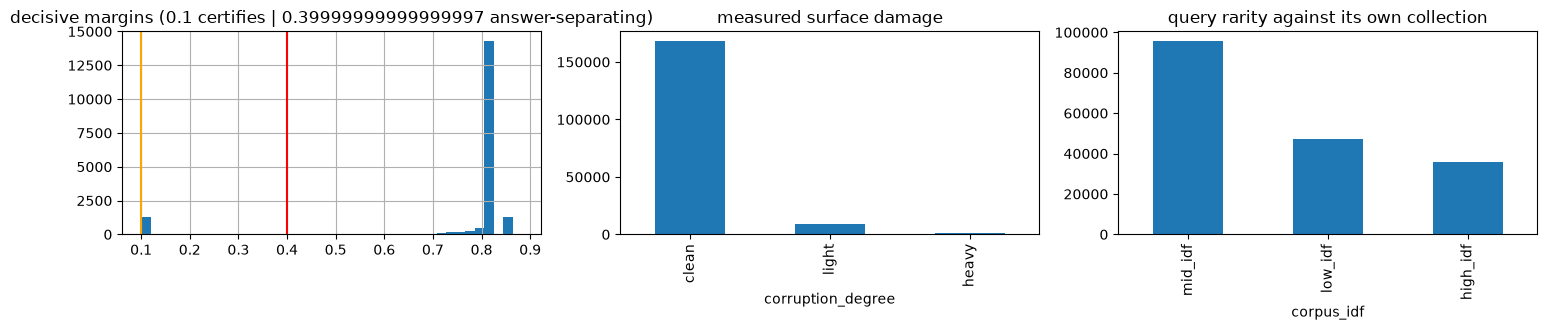

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
native.loc[native["kind"] == "decisive", "margin"].hist(bins=40, ax=axes[0])
axes[0].axvline(recipe.class_margin, color="orange")
axes[0].axvline(RouterObjective().decisive_margin, color="red")
axes[0].set_title(f"decisive margins ({recipe.class_margin} certifies | "
                  f"{RouterObjective().decisive_margin} answer-separating)")
native["corruption_degree"].value_counts().plot.bar(ax=axes[1])
axes[1].set_title("measured surface damage")
native["corpus_idf"].value_counts().plot.bar(ax=axes[2])
axes[2].set_title("query rarity against its own collection")
plt.tight_layout()
plt.show()

## 4. Four decisions, four measurements

v3 is an extension of v2, not a replacement — same retrieval stack, same
objective, same label semantics. Four things changed. Each subsection states
what v2 did, what v3 does instead, and measures the difference with a function
the pipeline already owns. None of these cells re-runs a selection; if one
takes more than a second, something is wrong.

### 4a. The archetype vocabulary went 44 → 63 cells

v2 had 44 cells. 26 identifier extractors had no cell that could claim them, so
a query built around a MAC address, an EU regulation citation or a clinical
code was invisible to composition — it existed in the catalog and belonged to
nothing. v3 adds 19 cells: six that pool those orphaned extractors, three
damage rungs, and rarity / vocabulary / length archetypes.

The cells are added because the archetype exists, not because supply does —
`k_cap` bounds any one cell's allocation to a multiple of its own catalog
share, which is what lets breadth be declared ahead of mass.

In [9]:
def cell_coverage(cells: tuple) -> dict:
    marginals = DiversityFloors(recipe, cells).marginals(shelf)
    cell_rows = marginals[marginals["axis"] == "cell"]
    return {
        "cells declared": len(cell_rows),
        f"cells at or above the floor of {recipe.stratum_floor}": int(
            cell_rows["met"].sum()
        ),
        "cells with zero rows on the shelf": int((cell_rows["rows"] == 0).sum()),
        "strata declared across all axes": len(marginals),
    }


pd.DataFrame(
    {"v2 cell set": cell_coverage(tuple(CELLS)), "v3 cell set": cell_coverage(CELL_SET)}
)

,v2 cell set,v3 cell set
cells declared,44,63
cells at or above the floor of 25,15,27
cells with zero rows on the shelf,17,22
strata declared across all axes,55,74


In [10]:
pd.DataFrame(
    [
        {
            "cell": cell.name,
            "predicts": ", ".join(cell.predicts),
            "archetype": " ".join((cell.looks_like or "").split())[:76],
        }
        for cell in CELLS_V3
    ]
).set_index("cell")

,predicts,archetype
cell,,
rare_term_query,sparse,a query built around uncommon/technical vocabulary
fragmented_query,dense,a query with a long or unusual term (phosphorylation-class)
typo_bearing_query,dense,a real query with a single-character typo (confgure -> configure)
high_oov_query,dense,a query dense with jargon or novel terms
artifact_corrupted_query,hybrid,"a query with encoding junk, HTML residue, or a cut-off ending"
network_device_identity,sparse,A hardware or subscriber identity in up to nine words: a colon- or dash-sepa
corporate_registry_code,sparse,A company- or market-level registry code in up to nine words: a twenty-chara
statutory_instrument_citation,sparse,A European or industrial-property citation in up to nine words: an ECLI or b
clinical_chemical_code,sparse,A biomedical code in up to nine words: a CPT/SNOMED/LOINC/DRG procedure or d


### 4b. The taxonomy grew the columns those cells band on

Adding a cell is free; making it measurable is not. v3's catalog carries five
feature groups v2's did not, and the previously orphaned identifier extractors
now have columns at all.

The reason is a measured gap, not taste: on v2's features, 71% of the queries
where sparse retrieval won were *feature-invisible* — nothing in the extractor
set separated them from the dense wins. The missing signal was term rarity, so
`term_rarity` (global word frequency) and `query_corpus` (rarity against the
collection actually being searched) exist to close it.

The counterfactual is what a cell set can even be evaluated on: `active_cells`
drops any cell banding on a column the catalog in hand lacks.

In [11]:
v2_catalog = with_derived(read_catalog(DATA / "feature_table" / "catalog.parquet"))
v3_catalog = with_derived(read_catalog(DATA / "v3" / "catalog_v3.parquet"))


def schema(catalog: pd.DataFrame) -> dict:
    feature_columns = [c for c in catalog.columns if "." in c]
    return {
        "feature columns": len(feature_columns),
        "feature groups": len({c.split(".")[0] for c in feature_columns}),
        "identifier extractors": sum(
            c.startswith("structured_identifiers.") for c in feature_columns
        ),
        "cells with every column present": len(labelled.active_cells(catalog)),
    }


groups_v2 = {c.split(".")[0] for c in v2_catalog.columns if "." in c}
groups_v3 = {c.split(".")[0] for c in v3_catalog.columns if "." in c}
print("groups v3 added:", sorted(groups_v3 - groups_v2))
pd.DataFrame({"v2 catalog": schema(v2_catalog), "v3 catalog": schema(v3_catalog)})

groups v3 added: ['corruption', 'query_corpus', 'subword_fragmentation', 'term_rarity', 'unknown_token_rate']


,v2 catalog,v3 catalog
feature columns,74,117
feature groups,10,15
identifier extractors,54,79
cells with every column present,52,63


### 4c. Surface damage became an axis, because it moves the answer

`corrupt` takes a labelled query, damages its surface at the rate the
corruption census measured in real traffic — mojibake, paste residue, typos —
and the damaged twin is **relabelled from scratch**. Both halves of every pair
therefore carry an independently measured route.

That is the whole justification for spending a diversity axis on damage: if the
route never changed, damage would be dirt to clean rather than a dimension to
cover.

In [12]:
generated = GeneratedPool().load()
corrupted = generated[generated["operator"] == "corrupt"]
FIELDS = ["dataset", "query_id", "query", "route_class_any", "margin"]

child = corrupted.assign(
    dataset=corrupted["home_lane"].astype(str),
    query_id=corrupted["query_id"].astype(str),
    parent_dataset=corrupted["parent_dataset"].astype(str),
    parent_id=corrupted["generated_from"].astype(str),
)[["dataset", "query_id", "parent_dataset", "parent_id"]]

sides = native[FIELDS].astype({"dataset": str, "query_id": str})
pairs = (
    child.merge(sides.add_suffix("_damaged"),
                left_on=["dataset", "query_id"],
                right_on=["dataset_damaged", "query_id_damaged"])
    .merge(sides.add_suffix("_clean"),
           left_on=["parent_dataset", "parent_id"],
           right_on=["dataset_clean", "query_id_clean"])
)
flipped = pairs["route_class_any_clean"] != pairs["route_class_any_damaged"]
both_routed = (pairs["route_class_any_clean"] != "") & (
    pairs["route_class_any_damaged"] != ""
)
print(f"damaged twins with BOTH sides independently labelled: {len(pairs):,}")
print(f"winning route changed after damage                  : {flipped.mean():.1%}")
print(f"  ...route -> a different route                     : "
      f"{int((flipped & both_routed).sum()):,}")
print(f"  ...signal lost entirely (became a tie or all-zero): "
      f"{int((flipped & ~both_routed).sum()):,}")

# route -> route flips only; losing the signal is a different outcome and the
# crosstab below counts it separately
pairs.loc[
    flipped & both_routed,
    ["query_clean", "query_damaged", "route_class_any_clean",
     "route_class_any_damaged"],
].sample(6, random_state=5)

damaged twins with BOTH sides independently labelled: 6,439
winning route changed after damage                  : 21.1%
  ...route -> a different route                     : 665
  ...signal lost entirely (became a tie or all-zero): 694


,query_clean,query_damaged,route_class_any_clean,route_class_any_damaged
4703,Why might the ICESat-2 DEM offer significant accuracy improvements over other altimeter-deri...,Why might the ICESat-2 DEM offer significant accuracy improvements over other altimeter-deri...,sparse,hybrid
3320,su vs sudo -s vs sudo -i vs sudo bash,su vs sudo -s vs sudo -i vs sudo bÃ¡sh,sparse,dense
866,Vietnamese or South Korean supernatural horror films,Vietnamese or South Korean supernatural horror fÃ­lms,sparse,hybrid
4554,Plants from Montana and trees from Western Canada and North America,Plants from Montana and trÃ©es from Western Canada and North America,sparse,dense
2238,What are the key characteristics of high-resolution images used for phylogenetic analysis in...,What Ã¡re the key characteristics of high-resolution images used for phylogenetic analysis i...,dense,hybrid
4614,I am currently developing an application that can efficiently search for images relevant to ...,I am currently developing an application that can efficiently search for images relevant to ...,dense,hybrid


In [13]:
NO_SIGNAL = "(no usable signal: tie or all-zero)"
crosstab = pd.crosstab(
    pairs["route_class_any_clean"].replace("", NO_SIGNAL),
    pairs["route_class_any_damaged"].replace("", NO_SIGNAL),
    rownames=["clean"],
    colnames=["damaged"],
)
crosstab

damaged,(no usable signal: tie or all-zero),dense,hybrid,sparse
clean,,,,
(no usable signal: tie or all-zero),301,7,7,7
dense,271,2409,122,58
hybrid,44,71,374,119
sparse,358,69,226,1996


The blank row and column that used to sit in this table were not a fourth route
— they are pairs where one side lost its signal entirely (a tie or an all-zero),
which is a different outcome from switching route and is now named as such.

### 4d. One flat quota became three layered objectives

v2 optimized one thing: fill a flat quota per cell (`n_per_route`, 200 per
route per cell). No target split, no certification tier, no frozen evaluation
reserve — and, as §1 showed, no hybrid class at all.

v3 layers three objectives so they cannot collide:

- **diversity** is a set of hard floors — constraints on what must be covered.
- **utility** is the only thing maximized: source × route coverage, with cells
  and the other strata breaking ties.
- **representation** is a *bound* checked after the fact, never a selection-time
  prior on what is common.

The measurable consequence is `feasible_total`: the largest artifact whose
per-class targets still fit supply once no single source may exceed
`target_lane_share`. Turning that cap off tells you exactly what balance costs.

In [14]:
selectable = labelled.selectable()
tier0_counts = {
    c: selectable.loc[selectable["route_class_any"] == c, "dataset"].value_counts()
    for c in ("dense", "sparse", "hybrid")
}
uncapped = UtilityObjective.feasible_total(tier0_counts, recipe.target_split, 1.0)
capped = UtilityObjective.feasible_total(
    tier0_counts, recipe.target_split, recipe.target_lane_share
)
binding = min(
    zip(("dense", "sparse", "hybrid"), recipe.target_split),
    key=lambda cs: tier0_counts[cs[0]].sum() / cs[1],
)[0]

print(f"tier-0 supply, per class : "
      f"{ {c: int(v.sum()) for c, v in tier0_counts.items()} }")
print(f"largest artifact, no source cap    : {uncapped:,} rows")
print(f"largest artifact, {recipe.target_lane_share:.0%} source cap : {capped:,} rows"
      f"  ({1 - capped / uncapped:.0%} smaller)")
print(f"the class that binds the total     : {binding}")
print(f"shipped shelf                      : {len(shelf):,} rows "
      f"(tier-0 draw plus {recipe.waste_cap:.0%} dictated waste)")

tier-0 supply, per class : {'dense': 32480, 'sparse': 24054, 'hybrid': 21624}
largest artifact, no source cap    : 53,453 rows
largest artifact, 20% source cap : 35,074 rows  (34% smaller)
the class that binds the total     : sparse
shipped shelf                      : 36,711 rows (tier-0 draw plus 5% dictated waste)


### 4e. The cap moved from inside each cell to across the whole artifact

Both generations use the same 20% number; they enforce it differently, and that
is the difference that shows.

v2 applied it *per cell*, and relaxed it whenever a cell could not reach it from
supply. The report was green — no cell exceeded its own cap — because the cap
had already been lowered to fit.

v3 applies it *globally* and shrinks the total until it holds strictly, which is
the `feasible_total` search above. Compare what each generation reported against
what it shipped:

In [15]:
v2_report = pd.read_parquet(DATA / "composition" / "cell_report.parquet")
shipped_share = (
    v2_shelf.groupby("cell")["dataset"]
    .agg(lambda col: col.value_counts(normalize=True).iloc[0])
)
print("v2, as reported per cell:")
print(f"   worst cap actually recorded   : "
      f"{v2_report['lane_share_achieved'].max():.1%}")
print(f"   cells whose cap was relaxed   : "
      f"{int(v2_report['lane_share_infeasible'].sum())} of {len(v2_report)}")
print("v2, as shipped per cell:")
print(f"   median cell's top-source share: {shipped_share.median():.1%}")
print(f"   worst cell                    : {shipped_share.max():.1%} "
      f"({shipped_share.idxmax()})")
print(f"   cells above the 20% target    : "
      f"{int((shipped_share > 0.2).sum())} of {len(shipped_share)}")
print()
concentration = pd.DataFrame(
    {
        "top source": [
            native["dataset"].value_counts(normalize=True).index[0],
            shelf["dataset"].value_counts(normalize=True).index[0],
            shelf[shelf["certified"]]["dataset"].value_counts(normalize=True).index[0],
        ],
        "its share": [
            f"{native['dataset'].value_counts(normalize=True).iloc[0]:.1%}",
            f"{shelf['dataset'].value_counts(normalize=True).iloc[0]:.1%}",
            f"{shelf[shelf['certified']]['dataset'].value_counts(normalize=True).iloc[0]:.1%}",
        ],
    },
    index=["v3 supply (uncapped inventory)", "v3 shelf (capped)",
           "v3 certified (capped)"],
)
concentration

v2, as reported per cell:
   worst cap actually recorded   : 19.8%
   cells whose cap was relaxed   : 27 of 44
v2, as shipped per cell:
   median cell's top-source share: 45.3%
   worst cell                    : 100.0% (rare_key_buried_in_chatter)
   cells above the 20% target    : 31 of 37



,top source,its share
v3 supply (uncapped inventory),scirgen-geo-en,30.1%
v3 shelf (capped),scirgen-geo-en,20.1%
v3 certified (capped),scirgen-geo-en,18.5%


## 5. Where v3 is currently worse

Six of them. Five have the same root cause and it is worth naming plainly: v2
skimmed the easy top of the natural well, and v3 worked the remainder.

In [16]:
def tier0_rate(frame: pd.DataFrame) -> float:
    live = frame[~frame["is_waste"] & (frame["route_class_any"] != "")]
    return len(live) / len(frame)


marginals = DiversityFloors(recipe, CELL_SET).marginals(shelf)
inversion = pd.read_parquet(DATA / "v3" / "inversion_bound.parquet")
census = pd.read_parquet(AugmentationConfig().paths.corruption_census)
census_rate = float(
    (census["n_sampled"] * census["any_span"]).sum() / census["n_sampled"].sum()
)
damaged = shelf["corruption_degree"].isin(["light", "heavy"]).mean()

regressions = pd.DataFrame(
    [
        {
            "regression": "tier-0 rate (share of labels that are usable)",
            "v2": f"{tier0_rate(v2_supply):.1%}",
            "v3": f"{tier0_rate(native):.1%}",
            "why": "v2 skimmed the easy draw, v3 worked the remainder",
        },
        {
            "regression": "top source's share of supply",
            "v2": f"{v2_supply['dataset'].value_counts(normalize=True).iloc[0]:.1%}",
            "v3": f"{native['dataset'].value_counts(normalize=True).iloc[0]:.1%}",
            "why": "one source deepened; capped at the shelf, not in inventory",
        },
        {
            "regression": "genuine hybrid ties in supply",
            "v2": f"{int((v2_supply['kind'] == 'genuine_tie').sum()):,}",
            "v3": f"{int((native['kind'] == 'genuine_tie').sum()):,}",
            "why": f"depth {recipe.genuine_tie_depth} demoted shallow ties to fake",
        },
        {
            "regression": "damaged share vs census rate",
            "v2": "not measured",
            "v3": f"{damaged:.1%} vs {census_rate:.1%}",
            "why": "over-represented: the sheet is census-sized, the shelf is not",
        },
        {
            "regression": f"strata below the floor of {recipe.stratum_floor}",
            "v2": "not measured",
            "v3": f"{int((~marginals['met']).sum())} of {len(marginals)}",
            "why": "breadth declared ahead of supply by design, still unpaid",
        },
        {
            "regression": "worst over-representation ratio",
            "v2": "not measured",
            "v3": f"{inversion[~inversion['floor_forced']]['max_ratio'].max():.2f}x",
            "why": "reported only — the bound's K is not frozen, so it binds nothing",
        },
    ]
).set_index("regression")
with pd.option_context("display.max_colwidth", 66):
    display(regressions)

,v2,v3,why
regression,,,
tier-0 rate (share of labels that are usable),51.9%,45.8%,"v2 skimmed the easy draw, v3 worked the remainder"
top source's share of supply,18.7%,30.1%,"one source deepened; capped at the shelf, not in inventory"
genuine hybrid ties in supply,990,446,depth 2 demoted shallow ties to fake
damaged share vs census rate,not measured,10.3% vs 6.3%,"over-represented: the sheet is census-sized, the shelf is not"
strata below the floor of 25,not measured,37 of 74,"breadth declared ahead of supply by design, still unpaid"
worst over-representation ratio,not measured,5.75x,"reported only — the bound's K is not frozen, so it binds nothing"


The first row is the one that looks worst and means least. The *rate* fell while
the absolute count more than tripled — that is the signature of working a harder
remainder, not of worse labelling. Decomposed by where each row came from:

In [17]:
tier0_mask = ~native["is_waste"] & (native["route_class_any"] != "")
by_origin = pd.DataFrame(
    {
        "rows": rung.value_counts(),
        "tier-0 rate": tier0_mask.groupby(rung).mean().round(3),
        "certified rate": native["certified"].groupby(rung).mean().round(3),
    }
).sort_values("tier-0 rate", ascending=False)
v2_tier0 = v2_supply[~v2_supply["is_waste"] & (v2_supply["route_class_any"] != "")]
print(f"tier-0 rows, absolute: v2 {len(v2_tier0):,}  ->  v3 {int(tier0_mask.sum()):,}")
by_origin

tier-0 rows, absolute: v2 23,930  ->  v3 81,891


,rows,tier-0 rate,certified rate
provenance,,,
published: constructed from a template,723,0.909,0.433
published: humans wrote the queries,10045,0.553,0.110
"minted here: doc-grounded, retrieval-labelled",106802,0.511,0.124
published: authorship not ratified yet,8855,0.451,0.087
published: a model wrote the queries,52343,0.327,0.062


Minted rows out-yield what is left of the published supply. That is the
augmentation layer's actual job description: not to inflate a row count, but to
be the only source of new signal once the cheap end of a source is exhausted.

## 6. Composable: aim it at a bigger target

The last claim is the one that matters for whether this is a pipeline or a
one-off file. `target_total` is a dial, and moving it re-prices three separate
ledgers with three separate owners:

- **labelling** buys rows from sources we already have, at their measured yield.
- **the lane rung** mints doc-grounded rows into sources by the same yields,
  carrying whatever labelling cannot buy.
- **cell floors** cover archetypes that no amount of either will produce
  organically.

Summing any two of them misprices all three. The sweep below asks one question
of one owner: **if minting had to carry the whole class shortfall, how far could
it get?** It hands the full debt to the lane rung rather than netting out what
labelling would buy first — at the shipped target that is a difference of about
140 rows, so it is the right question and not a double-count, but it is an upper
bound on the mint order, not a work plan.

In [18]:
# grounding capacity, measured the way the composer measures it: a source's
# corpus size minus the documents already keyed to a minted query
paths = AugmentationConfig().paths
dirs = lane_dirs()
spent = (
    pd.read_parquet(paths.qrels, columns=["query_id"])["query_id"].astype(str)
    if paths.qrels.exists() else pd.Series(dtype=str)
)
yields = SelectionOrder.yields(pool)
capacity = {}
for lane in yields.index:
    corpus = paths.lane_corpus(dirs.get(str(lane), str(lane)))
    if not corpus.exists():
        continue
    used = int(spent.str.startswith(f"lane-{lane}-").sum()) if len(spent) else 0
    capacity[str(lane)] = max(0, ParquetFile(corpus).metadata.num_rows - used)
print(f"grounding documents available: {sum(capacity.values()):,} "
      f"across {len(capacity)} sources")

grounding documents available: 1,153,704 across 41 sources


In [19]:
rows = []
for target in (len(shelf), recipe.target_total, 500_000):
    scaled = Recipe.v3(target_total=target)
    debt = DiversityFloors(scaled, CELL_SET).class_debt(pool).set_index("route_class")
    ceiling = LaneOrder(scaled).build(
        debt["debt"].to_dict(), yields, pool, capacity
    ).loc[LaneOrder.FOOTER]
    slack = {c: ceiling[f"expected_{c}"] - debt.at[c, "debt"] for c in CLASSES}
    binds = min(slack, key=slack.get)
    rows.append(
        {
            "target": f"{target:,}",
            "owed (dense/sparse/hybrid)": "/".join(
                f"{int(debt.at[c, 'debt']):,}" for c in CLASSES
            ),
            "minting can reach": "/".join(
                f"{int(ceiling[f'expected_{c}']):,}" for c in CLASSES
            ),
            "tightest class": binds,
            "its slack": f"{int(slack[binds]):,}",
        }
    )
pd.DataFrame(rows).set_index("target")

,owed (dense/sparse/hybrid),minting can reach,tightest class,its slack
target,,,,
"36,711",0/0/0,0/0/0,dense,0
"200,000","56,264/63,777/0","61,980/64,067/46,628",sparse,290
"500,000","191,264/198,777/28,068","340,739/178,452/146,898",sparse,"-20,325"


Read the slack column, not the totals. Where it is positive the target is
reachable by minting into sources we already hold; where it goes negative the
answer stops being a generation dial and becomes an acquisition conversation —
new corpora, or deeper relevance judgments on the ones we have.

And the two generations are one dataset, not two. v2's rows are excluded from
the shelf by decision, not by capability: the same objective composes them, and
the only thing standing between the two is a boolean.

In [20]:
def artifact_size(frame: pd.DataFrame) -> int:
    counts = {
        c: frame.loc[frame["route_class_any"] == c, "dataset"].value_counts()
        for c in CLASSES
    }
    return UtilityObjective.feasible_total(
        counts, recipe.target_split, recipe.target_lane_share
    )


union = pd.concat([selectable, v2_supply])
pd.DataFrame(
    {
        "rows in scope": [len(selectable), len(union)],
        "artifact it supports": [
            f"{artifact_size(selectable):,}",
            f"{artifact_size(union):,}",
        ],
    },
    index=["v3-native only (what ships)", "v2 + v3 combined (what could)"],
)

,rows in scope,artifact it supports
v3-native only (what ships),175035,"35,074"
v2 + v3 combined (what could),221177,"48,292"


## 7. The build this page describes

Artifacts move. This is the one the numbers above came from, including the
hashes of every input that fed it — if these do not match your working tree,
re-run `compose_v3.py` before quoting anything here.

In [21]:
print(f"built     : {stamp['built_utc']}")
print(f"git head  : {stamp['git_head'][:12]}")
print(f"rows      : {stamp['rows']:,}  ({stamp['certified']:,} certified, "
      f"{stamp['uncertified']:,} not)")
print(f"reserve   : {stamp['eval_reserve_rows']:,} rows frozen BEFORE selection")
print("inputs    :")
for name, digest in stamp["inputs_sha256_16"].items():
    print(f"    {digest}  {name}")
assert stamp["rows"] == len(shelf), "provenance stamp does not match the shelf"
print("\nstamp agrees with the artifact on disk.")

built     : 2026-08-21T20:55:08+00:00
git head  : 9879970abd65
rows      : 36,711  (11,167 certified, 25,544 not)
reserve   : 3,733 rows frozen BEFORE selection
inputs    :
    76b9c0e657bb8291  labels_rederived.parquet
    183aad4645e034a5  labels.parquet
    95d599a47ee6b1c8  catalog_v3.parquet
    9b8bb98879acf230  query_corpus_stats.parquet

stamp agrees with the artifact on disk.
